### ⛹️‍♂️ Body Performance - PCA & t-SNE

# ℹ️ About Dataset 

This is data that confirmed the grade of performance with age and some exercise performance data.

Link : https://www.kaggle.com/datasets/kukuroo3/body-performance-data

# 🔑 Key Features 

* **age** : 20 ~64
* **gender** : F,M
* **height_cm** : (If you want to convert to feet, divide by 30.48)
* **weight_kg**
* **body fat_%**
* **diastolic** : diastolic blood pressure (min)
* **systolic** : systolic blood pressure (min)
* **gripForce**
* **sit and bend forward_cm**
* **sit-ups counts**
* **broad jump_cm**
* **class** : A,B,C,D ( A: best) / stratified

# Source

link (Korea Sports Promotion Foundation)
Some post-processing and filtering has done from the raw data.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , classification_report
from sklearn.metrics import precision_score , recall_score , f1_score ,accuracy_score
from sklearn.metrics import RocCurveDisplay

# Load Data

In [2]:
data = pd.read_csv(r'C:\Users\stfal\OneDrive\Desktop\MachineLearning\Project-1\Lab5_PCA_TSNE\dataset\bodyPerformance.csv')
data = data.sample(frac=1).reset_index(drop=True)
data = data[:3000]
data.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,61.0,M,172.1,76.00,29.9,97.0,154.0,41.7,13.2,38.0,199.0,A
1,24.0,M,176.3,73.00,15.4,89.0,129.0,46.2,21.1,59.0,256.0,A
2,25.0,M,177.5,75.90,21.7,86.0,152.0,41.8,22.2,57.0,237.0,B
3,24.0,M,170.9,63.10,11.7,62.0,115.0,40.2,8.4,42.0,229.0,C
4,26.0,M,180.8,69.26,13.6,80.0,120.0,44.0,1.5,53.0,249.0,D


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      3000 non-null   float64
 1   gender                   3000 non-null   object 
 2   height_cm                3000 non-null   float64
 3   weight_kg                3000 non-null   float64
 4   body fat_%               3000 non-null   float64
 5   diastolic                3000 non-null   float64
 6   systolic                 3000 non-null   float64
 7   gripForce                3000 non-null   float64
 8   sit and bend forward_cm  3000 non-null   float64
 9   sit-ups counts           3000 non-null   float64
 10  broad jump_cm            3000 non-null   float64
 11  class                    3000 non-null   object 
dtypes: float64(10), object(2)
memory usage: 281.4+ KB


In [4]:
# Check for null data
data.isnull().sum() 

age                        0
gender                     0
height_cm                  0
weight_kg                  0
body fat_%                 0
diastolic                  0
systolic                   0
gripForce                  0
sit and bend forward_cm    0
sit-ups counts             0
broad jump_cm              0
class                      0
dtype: int64

In [5]:
data['class'].unique()

array(['A', 'B', 'C', 'D'], dtype=object)

In [6]:
# Select columns with data type 'object'
for col in data.columns :
    if data[col].dtypes == 'object' : 
        print(col)

gender
class


In [7]:
# Create encoding for object cols 
unique_gender = np.unique(data['gender'])
data['gender'] = [ ((g == unique_gender).astype(int)).argmax() for g in data['gender']]
unique_class = np.unique(data['class'])
data['class'] = [ ((c == unique_class).astype(int)).argmax() for c in data['class']]
data.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,61.0,1,172.1,76.00,29.9,97.0,154.0,41.7,13.2,38.0,199.0,0
1,24.0,1,176.3,73.00,15.4,89.0,129.0,46.2,21.1,59.0,256.0,0
2,25.0,1,177.5,75.90,21.7,86.0,152.0,41.8,22.2,57.0,237.0,1
3,24.0,1,170.9,63.10,11.7,62.0,115.0,40.2,8.4,42.0,229.0,2
4,26.0,1,180.8,69.26,13.6,80.0,120.0,44.0,1.5,53.0,249.0,3


In [8]:
data['class'].unique()

array([0, 1, 2, 3])

In [9]:
data_class = data['class'].value_counts().sort_index()
data_class

class
0    751
1    743
2    752
3    754
Name: count, dtype: int64

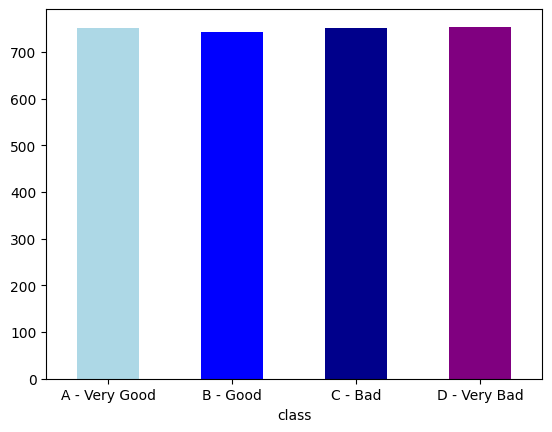

In [10]:
data_class.plot(kind='bar' , color=['lightblue','blue','darkblue','purple','black'])
plt.xticks(ticks=[0,1,2,3] , rotation=0 , labels=['A - Very Good' , 'B - Good' , 'C - Bad' , 'D - Very Bad'])
plt.show()

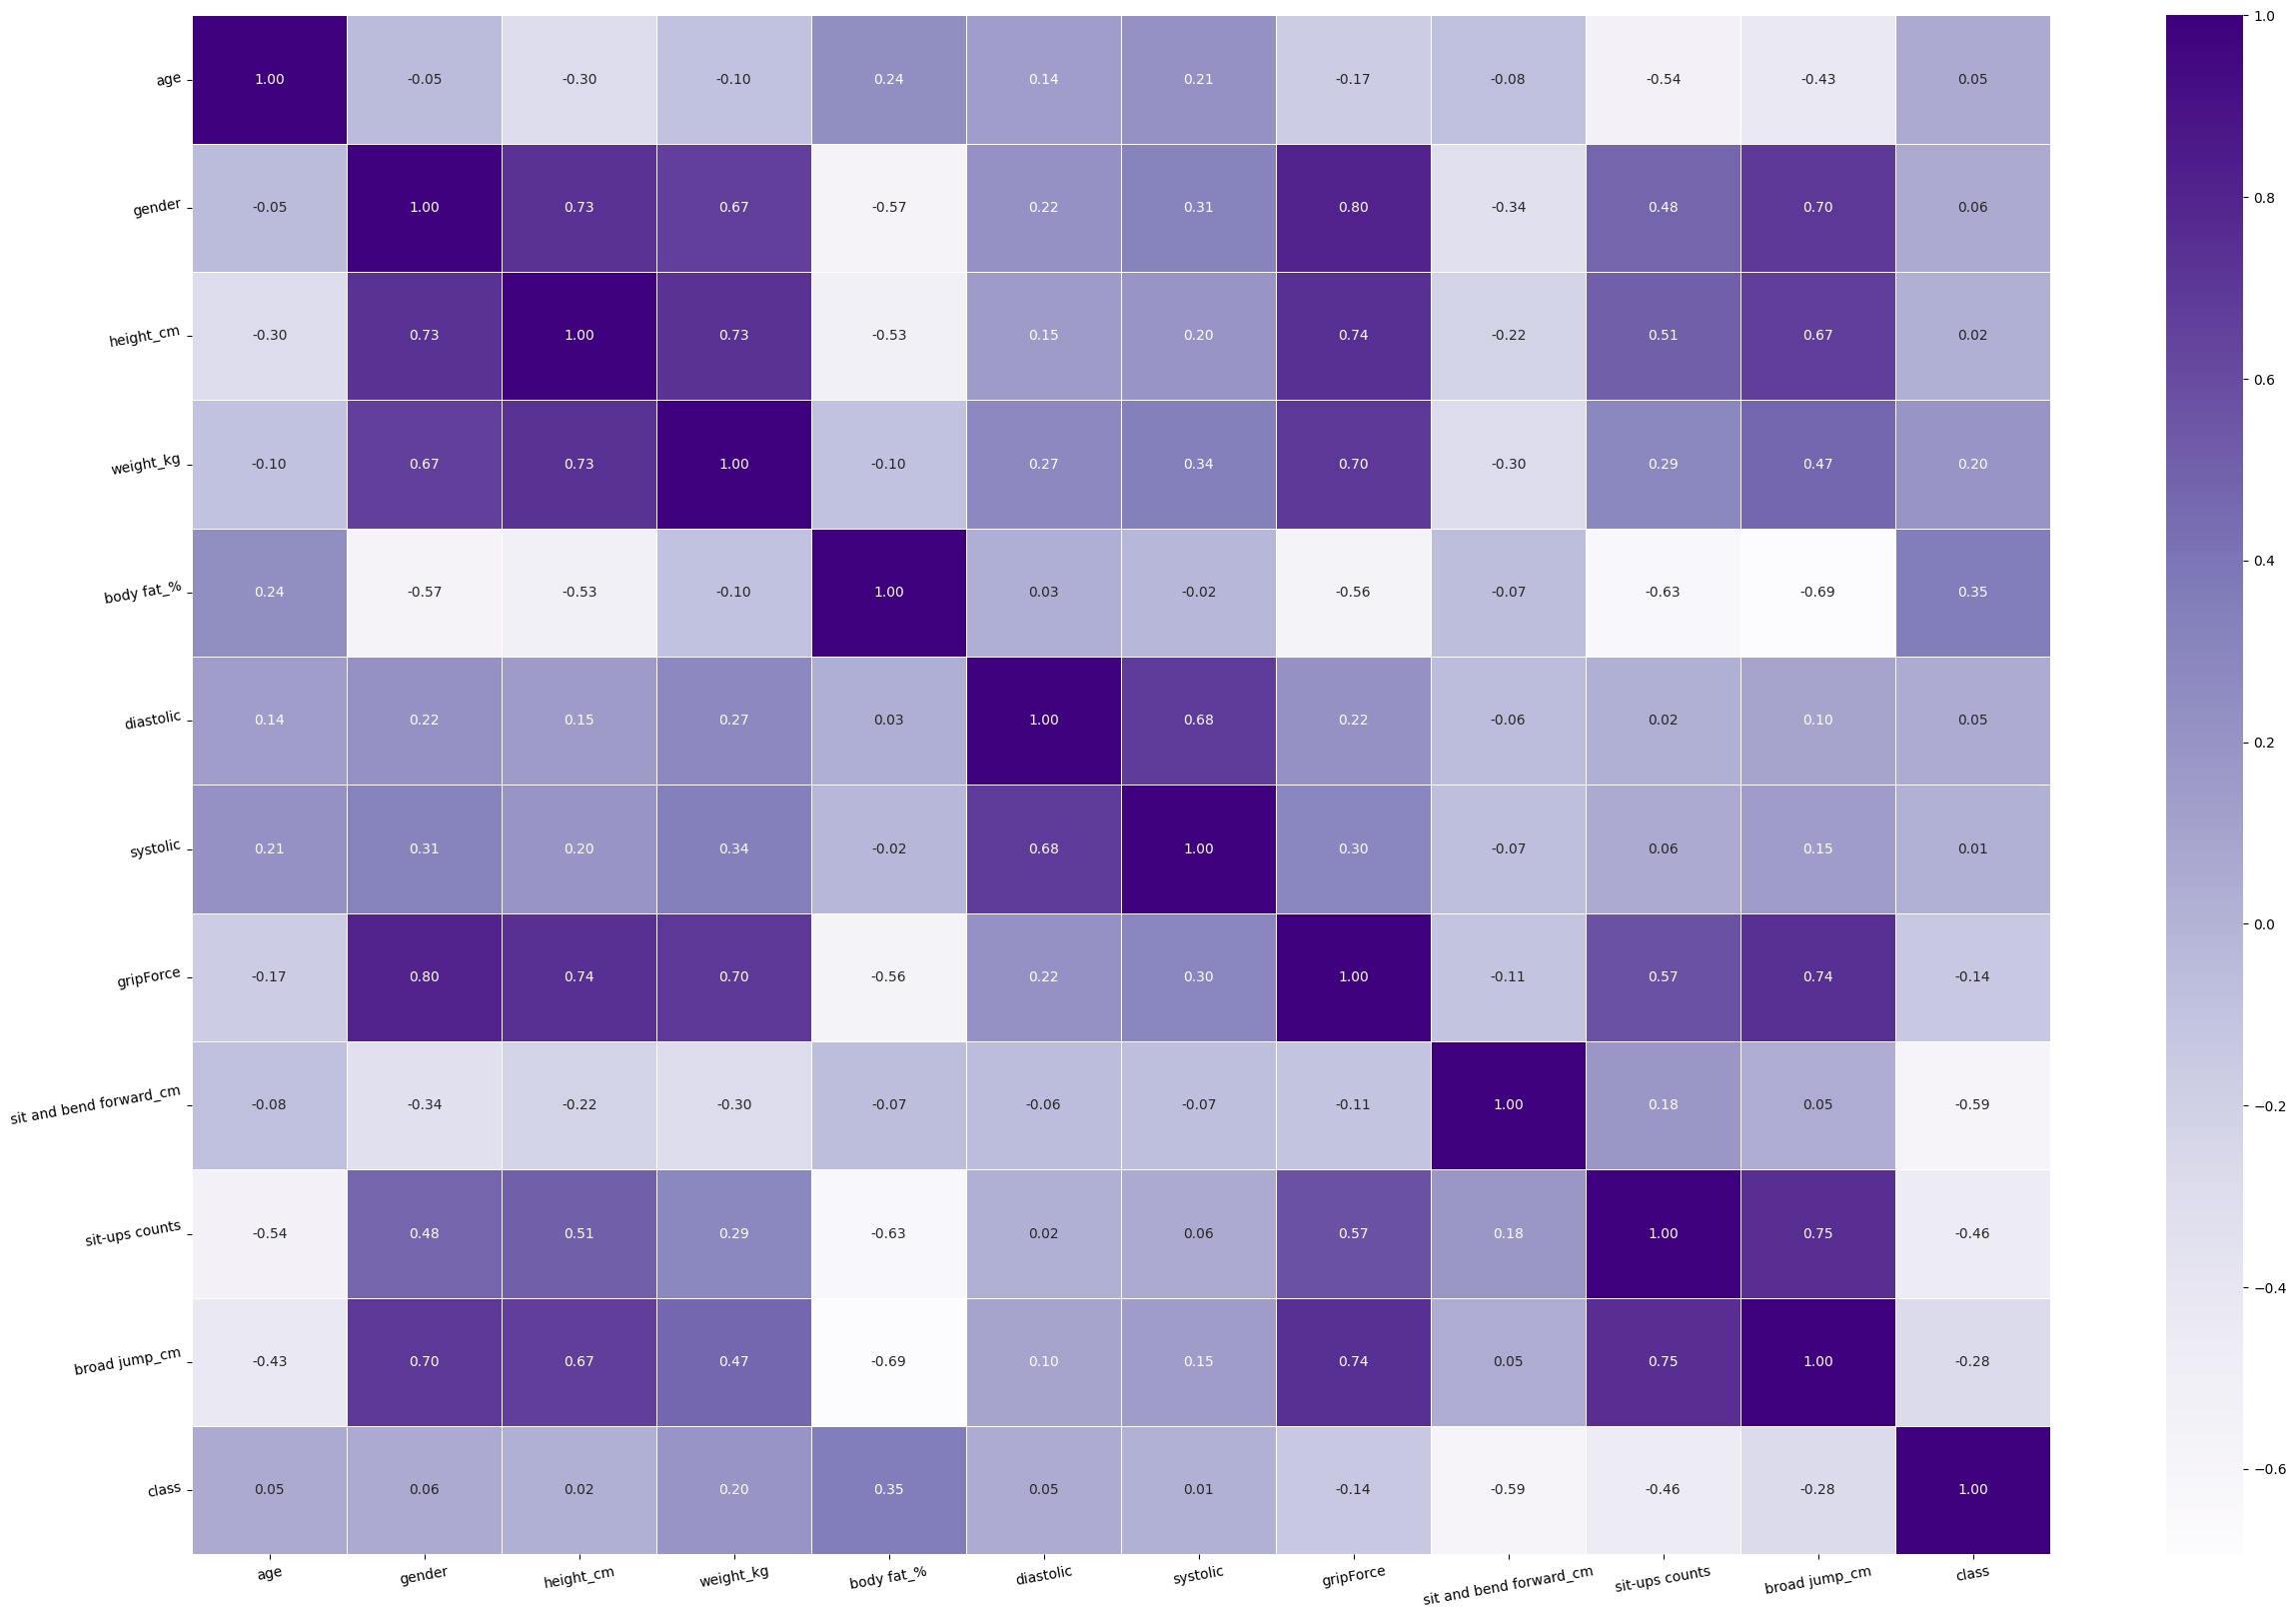

In [11]:
# Corelation Matrix 
corr_matrix = data.corr()
fix,ax = plt.subplots(figsize=(30,20))
ax = sns.heatmap(corr_matrix , annot=True , linewidths=0.5 , fmt='.2f' , cmap='Purples');
plt.xticks(rotation=10)
plt.yticks(rotation=10)
plt.show()

### Create X & y and split the data

In [12]:
X = data.drop('class' , axis=1)
y = data['class']

In [13]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)
len(X_train) , len(y_train) , len(X_test) , len(y_test)

(2400, 2400, 600, 600)

In [14]:
# Preprocessing data - standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

X_scaled = scaler.fit_transform(X)

In [15]:
# Import PCA & t-SNE
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [16]:
# Plot function 
def plot_2D(X, y , title) :
    hue_labels = ['D' , 'A' , 'C' , 'B']

    y_labels = [ hue_labels[val] for val in y]
    
    plt.figure(figsize=(7,5))
    sns.scatterplot(x=X[:,0] , y=X[:,1] , hue=y_labels , palette='Set2' , s=80)
    plt.title(title)
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.grid(True)
    plt.show()

# SVC without PCA

In [17]:
from sklearn.svm import SVC
import time 

svc = SVC(kernel='rbf' , C=1.0 , gamma='scale' , random_state=42)
svc_without_pca_score = {}

start_time = time.time()
svc.fit(X_train_scaled , y_train)
end_time = time.time() - start_time

score = svc.score(X_train_scaled , y_train)

print(f'Train time : {end_time*1000:.2f} ms')
print(f'Train Score : {score*100:.1f}%')

svc_without_pca_score['train_time'] = round(end_time * 1000 , 2)
svc_without_pca_score['train_score'] = round(score*100 , 2)

svc_without_pca_score[0] = {
     'components_number'  : 0,
     'train_time' : round(end_time * 1000 , 2),
}

Train time : 107.73 ms
Train Score : 70.6%


In [18]:
y_pred = svc.predict(X_test_scaled)
print(classification_report(y_test , y_pred))
svc_without_pca = accuracy_score(y_test , y_pred)
svc_without_pca_score[0] = {
    'components_number'  : 0,
    'train_time' : round(end_time * 1000 , 2),
    'acc_score' : round(svc_without_pca * 100 , 2)
}

              precision    recall  f1-score   support

           0       0.65      0.75      0.69       157
           1       0.46      0.47      0.46       155
           2       0.58      0.53      0.55       150
           3       0.86      0.76      0.81       138

    accuracy                           0.62       600
   macro avg       0.64      0.63      0.63       600
weighted avg       0.63      0.62      0.63       600



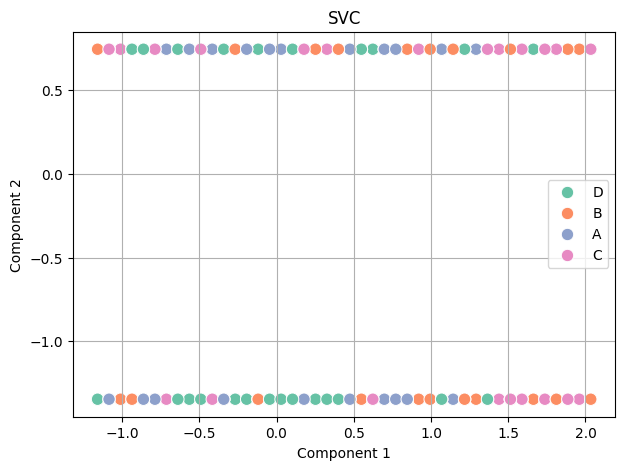

In [36]:
plot_2D(X_test_scaled , y_pred , 'SVC')

# SVC with PCA

In [19]:
svc_with_pca_results = {}
def svc_with_pca(n_comp) : 
    global svc_with_pca_results
    
    pca = PCA(n_components=n_comp)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    start_time = time.time()
    svc.fit(X_train_pca , y_train)
    end_time = time.time() - start_time
    
    score = svc.score(X_train_pca , y_train)
    
    print(f'Train time : {end_time*1000:.2f} ms')
    print(f'Train Score : {score*100:.1f}%')
    
    y_pred = svc.predict(X_test_pca)
    print(classification_report(y_test , y_pred))
    svc_with_pca = accuracy_score(y_test , y_pred)

    plot_2D(X_test_pca , y_pred , 'SVC With PCA')
    
    svc_with_pca_results[n_comp] = {
        'components_number' : n_comp,
        'train_time' : round(end_time*1000 , 2),
        'acc_score' : round(svc_with_pca * 100 , 2)
    }

Train time : 132.44 ms
Train Score : 42.7%
              precision    recall  f1-score   support

           0       0.45      0.49      0.47       157
           1       0.33      0.13      0.19       155
           2       0.40      0.33      0.36       150
           3       0.41      0.73      0.52       138

    accuracy                           0.41       600
   macro avg       0.40      0.42      0.39       600
weighted avg       0.40      0.41      0.38       600



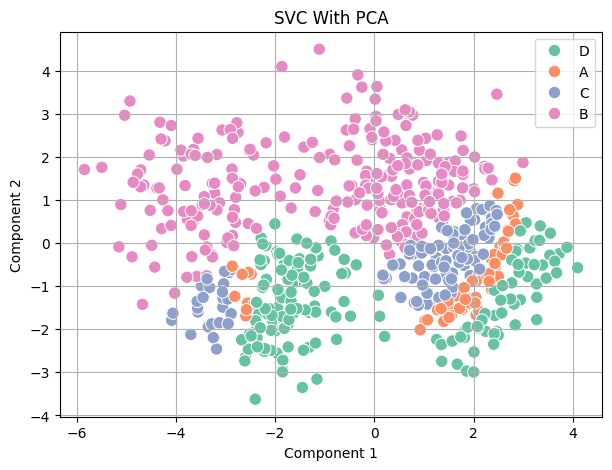

In [20]:
svc_with_pca(2)

Train time : 92.28 ms
Train Score : 65.2%
              precision    recall  f1-score   support

           0       0.63      0.76      0.69       157
           1       0.44      0.46      0.45       155
           2       0.57      0.48      0.52       150
           3       0.83      0.72      0.77       138

    accuracy                           0.61       600
   macro avg       0.62      0.61      0.61       600
weighted avg       0.61      0.61      0.61       600



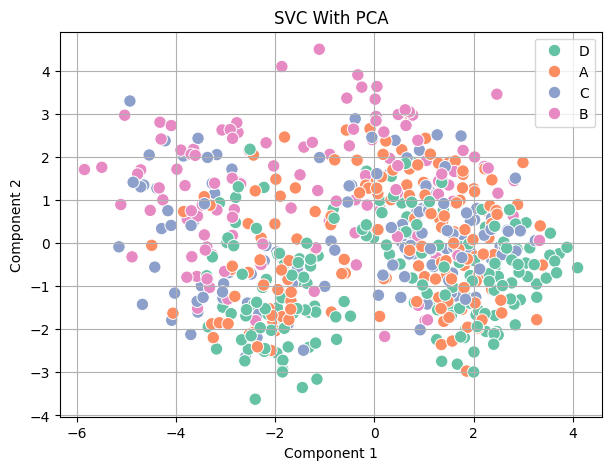

In [21]:
svc_with_pca(6)

Train time : 108.75 ms
Train Score : 70.2%
              precision    recall  f1-score   support

           0       0.65      0.75      0.70       157
           1       0.46      0.47      0.47       155
           2       0.58      0.55      0.56       150
           3       0.85      0.75      0.80       138

    accuracy                           0.62       600
   macro avg       0.64      0.63      0.63       600
weighted avg       0.63      0.62      0.63       600



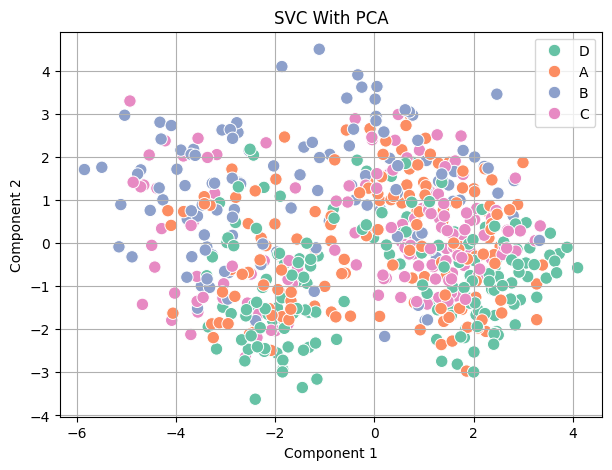

In [22]:
svc_with_pca(10)

# SVC with t-SNE

In [29]:
svc_with_tsne_score = {}
def svc_with_tsne(n_comp) :
    global svc_with_tsne_score
    
    tsne = TSNE(n_components=2)
    X_tsne = tsne.fit_transform(X_scaled)
    X_train_tsne, X_test_tsne, y_train_tsne, y_test_tsne = train_test_split(X_tsne, y, test_size=0.2, random_state=42)
    
    start_time = time.time()
    svc.fit(X_train_tsne , y_train_tsne)
    end_time = time.time() - start_time
    
    score = svc.score(X_train_tsne , y_train_tsne)
    
    print(f'Train time : {end_time*1000:.2f} ms')
    print(f'Train Score : {score*100:.1f}%')

    y_pred = svc.predict(X_test_tsne)
    print(classification_report(y_test_tsne , y_pred))
    svc_with_tsne = accuracy_score(y_test_tsne , y_pred)

    plot_2D(X_test_tsne , y_pred , 'SVC With TSNE')
    
    svc_with_tsne_score[n_comp] = {
          'components_number' : n_comp,
          'train_time' : round(end_time * 1000 , 2),
          'acc_score' : round(svc_with_tsne * 100 , 2)
    }

Train time : 150.83 ms
Train Score : 47.0%
              precision    recall  f1-score   support

           0       0.47      0.59      0.52       157
           1       0.35      0.15      0.21       155
           2       0.43      0.30      0.35       150
           3       0.44      0.74      0.55       138

    accuracy                           0.44       600
   macro avg       0.42      0.44      0.41       600
weighted avg       0.42      0.44      0.41       600



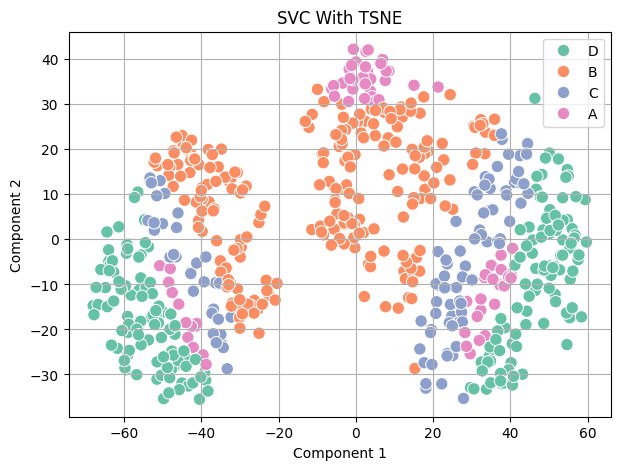

In [30]:
svc_with_tsne(2)

Train time : 158.59 ms
Train Score : 47.0%
              precision    recall  f1-score   support

           0       0.47      0.59      0.52       157
           1       0.35      0.15      0.21       155
           2       0.43      0.30      0.35       150
           3       0.44      0.74      0.55       138

    accuracy                           0.44       600
   macro avg       0.42      0.44      0.41       600
weighted avg       0.42      0.44      0.41       600



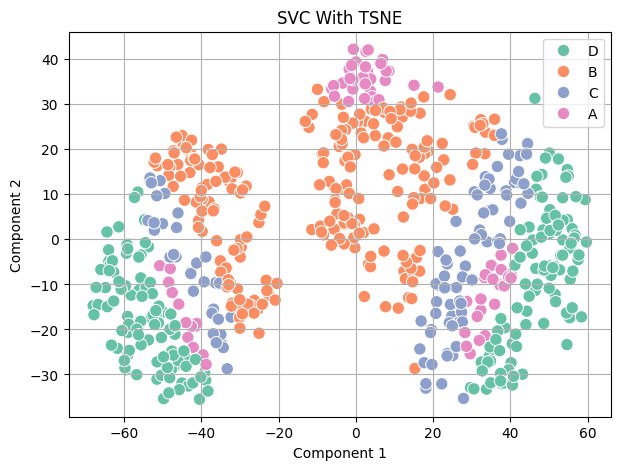

In [31]:
svc_with_tsne(6)

Train time : 149.37 ms
Train Score : 47.0%
              precision    recall  f1-score   support

           0       0.47      0.59      0.52       157
           1       0.35      0.15      0.21       155
           2       0.43      0.30      0.35       150
           3       0.44      0.74      0.55       138

    accuracy                           0.44       600
   macro avg       0.42      0.44      0.41       600
weighted avg       0.42      0.44      0.41       600



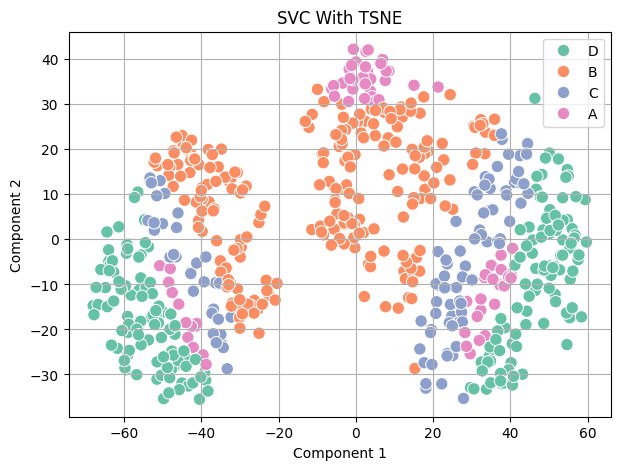

In [32]:
svc_with_tsne(10)

In [33]:
total_scores = {}

total_scores['SVC Without PCA'] = svc_without_pca_score[0]
total_scores['SVC With PCA - N_Comp 2'] = svc_with_pca_results[2]
total_scores['SVC With PCA - N_Comp 6'] = svc_with_pca_results[6]
total_scores['SVC With PCA - N_Comp 10'] = svc_with_pca_results[10]
total_scores['SVC With TSNE - N_Comp 2'] = svc_with_tsne_score[2]
total_scores['SVC With TSNE - N_Comp 6'] = svc_with_tsne_score[6]
total_scores['SVC With TSNE - N_Comp 10'] = svc_with_tsne_score[10]

scores = pd.DataFrame(total_scores)

def highlight_col(col):
    return ['background-color: #FFFF00' for _ in col] if col.name == 'SVC Without PCA' else ['' for _ in col]

In [34]:
scores.T.style.apply(highlight_col , axis=1)

,components_number,train_time,acc_score
SVC Without PCA,0.000000,107.730000,62.500000
SVC With PCA - N_Comp 2,2.000000,132.440000,41.170000
SVC With PCA - N_Comp 6,6.000000,92.280000,60.670000
SVC With PCA - N_Comp 10,10.000000,108.750000,62.500000
SVC With TSNE - N_Comp 2,2.000000,150.830000,43.830000
SVC With TSNE - N_Comp 6,6.000000,158.590000,43.830000
SVC With TSNE - N_Comp 10,10.000000,149.370000,43.830000
